<a href="https://colab.research.google.com/github/Oluwasamuel/3MTelecom_churn_Project/blob/main/911_Calls_Analysis_Capstone_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# 911 Calls Data Analysis Capstone Project

For this data analysis project we will be analyzing some 911 call data from [Kaggle](https://www.kaggle.com/mchirico/montcoalert). The data contains the following fields:

### Section 1: Data and Setup

____
**Import numpy and pandas**

In [ ]:
import numpy as np
import pandas as pd

**Import visualization libraries and set %matplotlib inline.**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

**Read in the csv file as a dataframe called df**

In [ ]:
df = pd.read_csv('911.csv')

**Check the info() of the df**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243627 entries, 0 to 243626
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   lat        243627 non-null  float64
 1   lng        243626 non-null  float64
 2   desc       243626 non-null  object 
 3   zip        214033 non-null  float64
 4   title      243626 non-null  object 
 5   timeStamp  243626 non-null  object 
 6   twp        243535 non-null  object 
 7   addr       243626 non-null  object 
 8   e          243626 non-null  float64
dtypes: float64(4), object(5)
memory usage: 16.7+ MB


**Check the head of df**

In [ ]:
df.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:10:52,NEW HANOVER,REINDEER CT & DEAD END,1.0
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:29:21,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1.0
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 14:39:21,NORRISTOWN,HAWS AVE,1.0
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 16:47:36,NORRISTOWN,AIRY ST & SWEDE ST,1.0
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 16:56:52,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1.0


### Section 2: Basic Questions

**What are the top 5 zipcodes for 911 calls?**

In [ ]:
top_zipcodes = df['zip'].value_counts().head(5)
print(top_zipcodes)

zip
19401.0    16858
19464.0    16443
19403.0    12273
19446.0    11720
19406.0     8054
Name: count, dtype: int64


**What are the top 5 townships (twp) for 911 calls?**

In [ ]:
top_townships = df['twp'].value_counts().head(5)
print(top_townships)

twp
LOWER MERION    20922
ABINGTON        14961
NORRISTOWN      14099
UPPER MERION    12779
CHELTENHAM      11243
Name: count, dtype: int64


**Take a look at the 'title' column, how many unique title codes are there?**

In [ ]:
unique_titles = df['title'].nunique()
print(unique_titles)

129


### Section 3: Creating new features

In [ ]:
df['Reason'] = df['title'].apply(lambda title: str(title).split(':')[0])
print(df['Reason'].head())

0     EMS
1     EMS
2    Fire
3     EMS
4     EMS
Name: Reason, dtype: object


**What is the most common Reason for a 911 call based off of this new column?**

In [ ]:
most_common_reason = df['Reason'].value_counts()
print(most_common_reason)

Reason
EMS        121671
Traffic     85458
Fire        36497
nan             1
Name: count, dtype: int64


**Now use seaborn to create a countplot of 911 calls by Reason.**

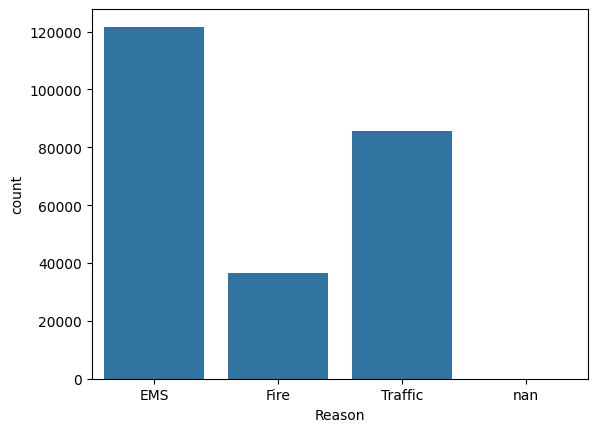

In [ ]:
sns.countplot(x='Reason', data=df)
plt.show()

___
**Now let us begin to focus on time information. What is the data type of the objects in the timeStamp column?**

In [ ]:
print(df['timeStamp'].dtype)

object


**You should have seen that these timestamps are still strings. Use [pd.to_datetime](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.to_datetime.html) to convert the column from strings to DateTime objects.**

In [ ]:
df['timeStamp'] = pd.to_datetime(df['timeStamp'])
display(df['timeStamp'].head())

,timeStamp
0,2015-12-10 17:10:52
1,2015-12-10 17:29:21
2,2015-12-10 14:39:21
3,2015-12-10 16:47:36
4,2015-12-10 16:56:52


**You can now grab specific attributes from a Datetime object by calling them. For example:**

    time = df['timeStamp'].iloc[0]
    time.hour

**You can use Jupyter's tab method to explore the various attributes you can call. Now that the timestamp column are actually DateTime objects, use .apply() to create 3 new columns called Hour, Month, and Day of Week. You will create these columns based off of the timeStamp column.**

In [ ]:
df['Hour'] = df['timeStamp'].apply(lambda x: x.hour)
df['Month'] = df['timeStamp'].apply(lambda x: x.month)
df['DayOfWeek'] = df['timeStamp'].apply(lambda x: x.dayofweek)

**Notice how the Day of Week is an integer 0-6. Use the .map() with this dictionary to map the actual string names to the day of the week:**

    dmap = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}

In [ ]:
dmap = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
df['DayOfWeek'] = df['DayOfWeek'].map(dmap)

**Now use seaborn to create a countplot of the Day of Week column with the hue based off of the Reason column.**

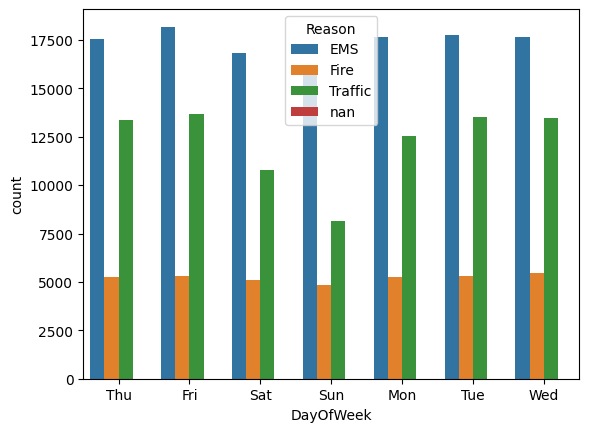

In [ ]:
sns.countplot(x='DayOfWeek', data=df, hue='Reason')
plt.show()

**Now do the same for Month:**

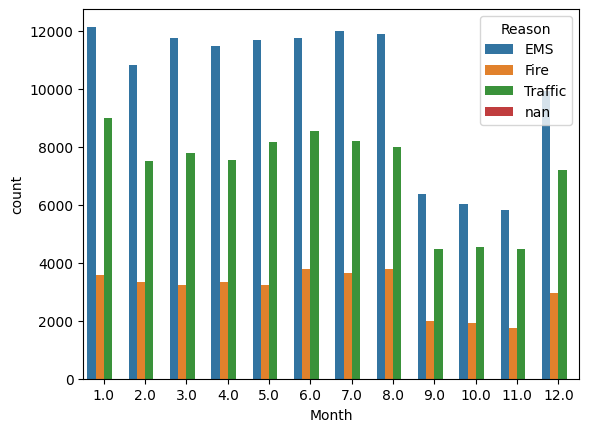

In [ ]:
sns.countplot(x='Month', data=df, hue='Reason')
plt.show()

**Did you notice something strange about the Plot?**

_____

**You should have noticed it was missing some Months, let's see if we can maybe fill in this information by plotting the information in another way, possibly a simple line plot that fills in the missing months, in order to do this, we'll need to do some work with pandas...**

**Now create a gropuby object called byMonth, where you group the DataFrame by the month column and use the count() method for aggregation. Use the head() method on this returned DataFrame.**

In [ ]:
byMonth = df.groupby('Month').count()
print(byMonth.head())

         lat    lng   desc    zip  title  timeStamp    twp   addr      e  \
Month                                                                      
1.0    24701  24701  24701  21877  24701      24701  24692  24701  24701   
2.0    21663  21663  21663  19161  21663      21663  21658  21663  21663   
3.0    22743  22743  22743  20160  22743      22743  22732  22743  22743   
4.0    22343  22343  22343  19671  22343      22343  22336  22343  22343   
5.0    23093  23093  23093  20254  23093      23093  23082  23093  23093   

       Reason   Hour  DayOfWeek  
Month                            
1.0     24701  24701      24701  
2.0     21663  21663      21663  
3.0     22743  22743      22743  
4.0     22343  22343      22343  
5.0     23093  23093      23093  


**Now create a simple plot off of the dataframe indicating the count of calls per month.**

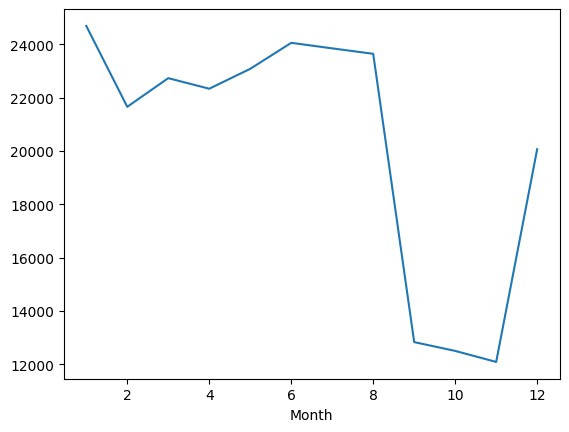

In [ ]:
byMonth['twp'].plot()
plt.show()

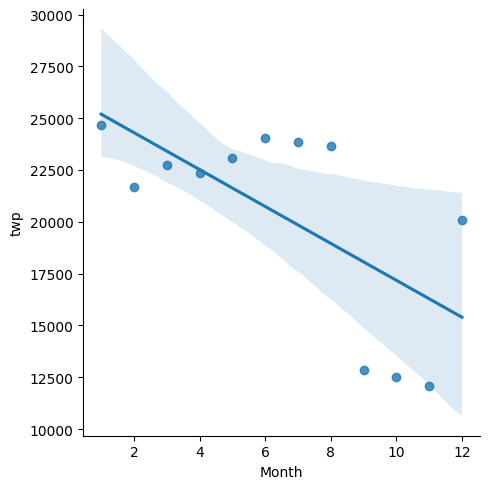

In [ ]:
sns.lmplot(x='Month', y='twp', data=byMonth.reset_index())
plt.show()

**Create a new column called 'Date' that contains the date from the timeStamp column. You'll need to use apply along with the .date() method.**

In [ ]:
df['Date'] = df['timeStamp'].apply(lambda x: x.date())
display(df['Date'].head())

,Date
0,2015-12-10
1,2015-12-10
2,2015-12-10
3,2015-12-10
4,2015-12-10


**Now groupby this Date column with the count() aggregate and create a plot of counts of 911 calls.**

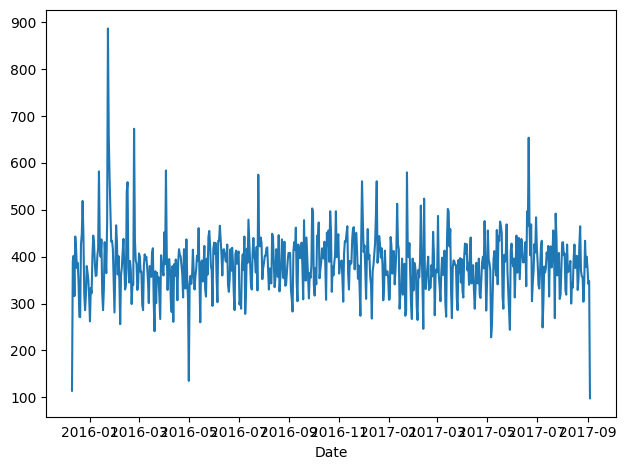

In [ ]:
byDate = df.groupby('Date').count()
byDate['twp'].plot()
plt.tight_layout()
plt.show()

**Now recreate this plot but create 3 separate plots with each plot representing a Reason for the 911 call**

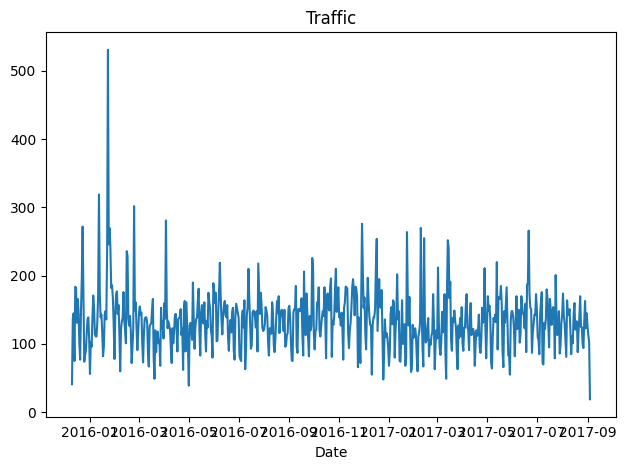

In [ ]:
df[df['Reason'] == 'Traffic'].groupby('Date').count()['twp'].plot()
plt.title('Traffic')
plt.tight_layout()
plt.show()

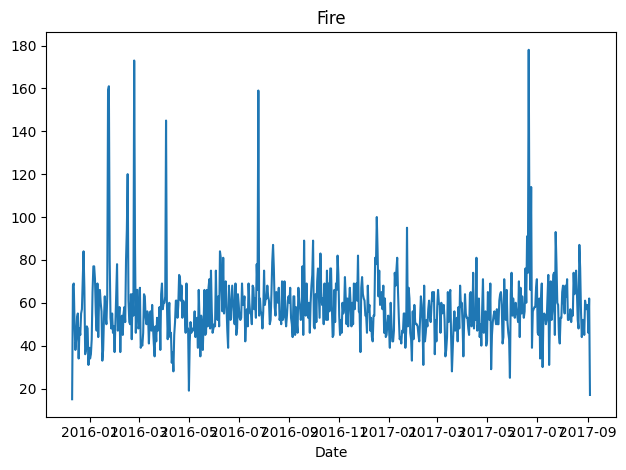

In [ ]:
df[df['Reason'] == 'Fire'].groupby('Date').count()['twp'].plot()
plt.title('Fire')
plt.tight_layout()
plt.show()

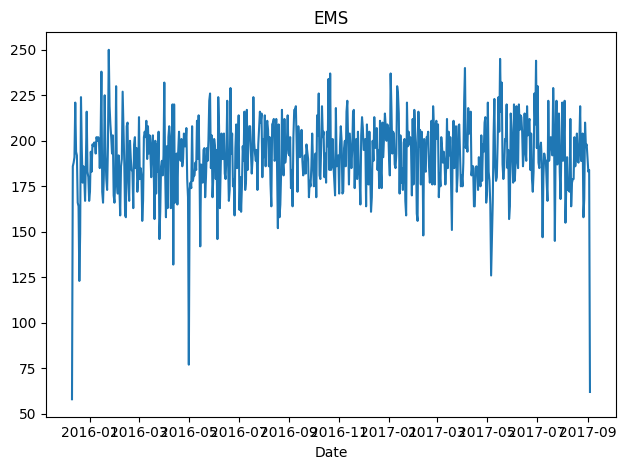

In [ ]:
df[df['Reason'] == 'EMS'].groupby('Date').count()['twp'].plot()
plt.title('EMS')
plt.tight_layout()
plt.show()

____
**Now let's move on to creating  heatmaps with seaborn and our data. We'll first need to restructure the dataframe so that the columns become the Hours and the Index becomes the Day of the Week. There are lots of ways to do this, but I would recommend trying to combine groupby with an [unstack](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.unstack.html) method.**

In [ ]:
dayHour = df.groupby(by=['DayOfWeek', 'Hour']).count()['Reason'].unstack()
print(dayHour.head())

Hour       0.0   1.0   2.0   3.0   4.0   5.0   6.0   7.0   8.0   9.0   ...  \
DayOfWeek                                                              ...   
Fri         650   596   541   482   456   560   967  1559  1826  1936  ...   
Mon         690   526   499   444   499   639   965  1615  2060  2090  ...   
Sat         855   738   681   599   555   585   723   943  1211  1541  ...   
Sun         872   770   761   625   541   571   674   891  1080  1445  ...   
Thu         657   504   539   447   436   608  1019  1679  1931  2054  ...   

Hour       14.0  15.0  16.0  17.0  18.0  19.0  20.0  21.0  22.0  23.0  
DayOfWeek                                                              
Fri        2264  2466  2551  2478  1938  1843  1607  1392  1309  1035  
Mon        2083  2278  2352  2378  2050  1652  1459  1147   982   749  
Sat        1979  1901  1939  1902  1871  1743  1519  1405  1222  1129  
Sun        1754  1650  1641  1710  1693  1539  1325  1160   898   835  
Thu        2195  2353

**Now create a HeatMap using this new DataFrame.**

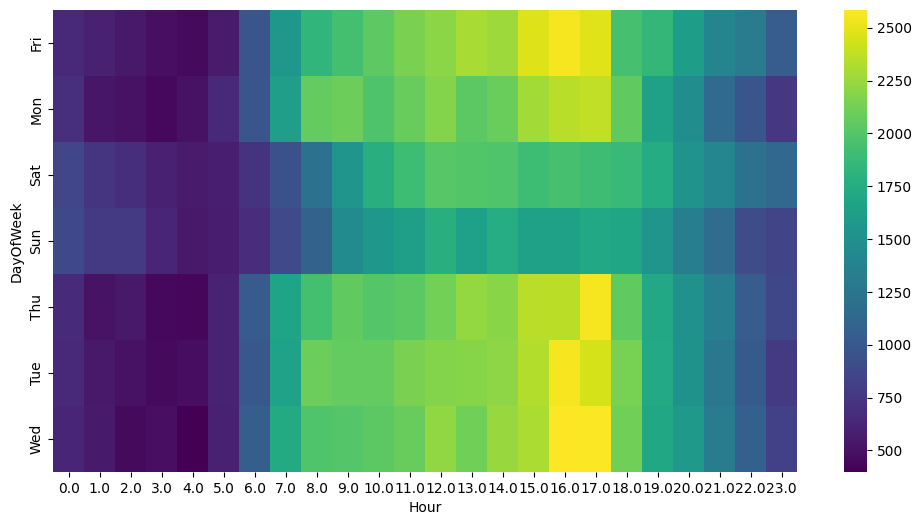

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(dayHour,cmap='viridis')
plt.show()

**Now create a clustermap using this DataFrame.**

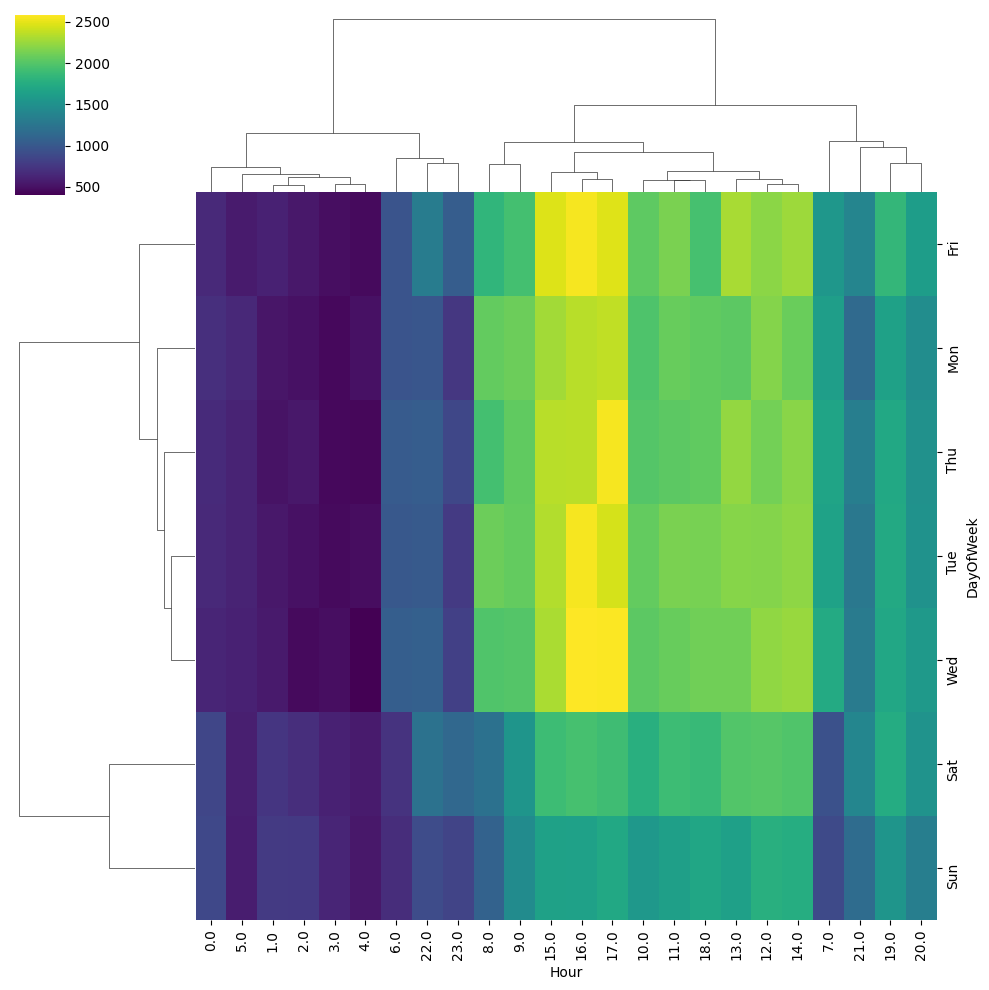

In [ ]:
sns.clustermap(dayHour,cmap='viridis')
plt.show()

**Now repeat these same plots and operations, for a DataFrame that shows the Month as the column.**

In [ ]:
dayMonth = df.groupby(by=['DayOfWeek', 'Month']).count()['Reason'].unstack()
print(dayMonth.head())

Month      1.0   2.0   3.0   4.0   5.0   6.0   7.0   8.0   9.0   10.0  11.0  \
DayOfWeek                                                                     
Fri        3527  3171  3532  3574  3278  3747  3736  3297  2572  1901  1699   
Mon        3706  3552  3103  3088  3538  3264  3687  3325  1650  2042  1682   
Sat        3527  2871  2539  3490  2764  3024  3515  2810  1748  1935  1516   
Sun        3470  2339  2229  3026  2580  2679  3259  2658  1583  1757  1281   
Thu        3182  3189  3909  3097  3289  4095  3248  3507  2165  1625  1630   

Month      12.0  
DayOfWeek        
Fri        3116  
Mon        2777  
Sat        2975  
Sun        2177  
Thu        3264  


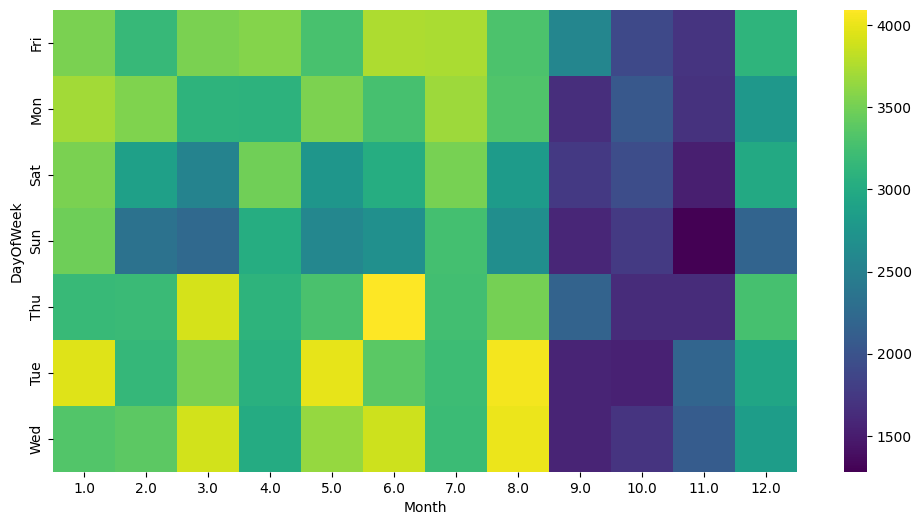

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(dayMonth,cmap='viridis')
plt.show()

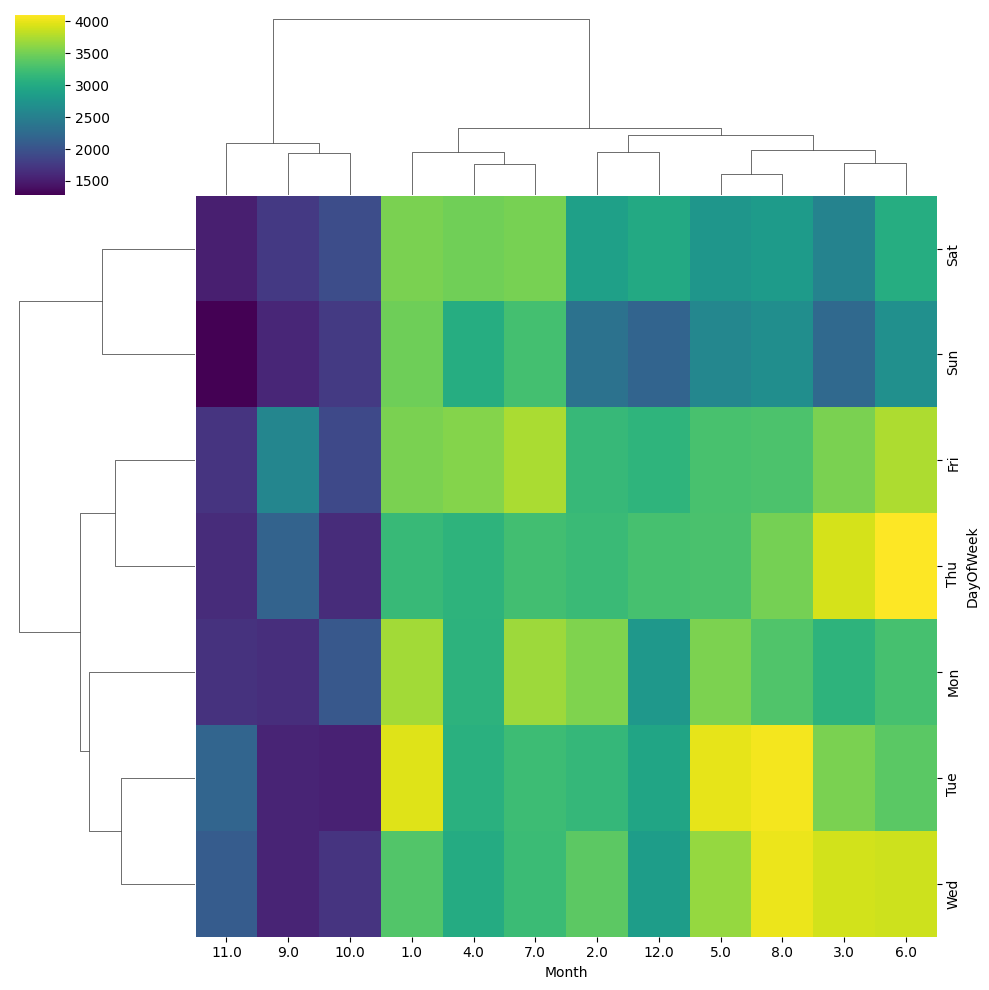

In [ ]:
sns.clustermap(dayMonth.fillna(0),cmap='viridis')
plt.show()

**Continue exploring the Data however you see fit!**
# Great Job!